In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

In [ ]:
# Agar Google Colab par run kar rahe hain to yeh line uncomment karein:
# from google.colab import files
# uploaded = files.upload()

# Local / GitHub par chalane ke liye seedha CSV file read hogi (agla cell dekhein)

In [3]:
df=pd.read_csv('insurance.csv')
df.head()

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


# **EDA**

In [4]:
df.shape

(1338, 7)

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   object 
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   object 
 5   region    1338 non-null   object 
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(2), object(3)
memory usage: 73.3+ KB


In [6]:
df.columns

Index(['age', 'sex', 'bmi', 'children', 'smoker', 'region', 'charges'], dtype='object')

In [7]:
df.describe()

,age,bmi,children,charges
count,1338.000000,1338.000000,1338.000000,1338.000000
mean,39.207025,30.663397,1.094918,13270.422265
std,14.049960,6.098187,1.205493,12110.011237
min,18.000000,15.960000,0.000000,1121.873900
25%,27.000000,26.296250,0.000000,4740.287150
50%,39.000000,30.400000,1.000000,9382.033000
75%,51.000000,34.693750,2.000000,16639.912515
max,64.000000,53.130000,5.000000,63770.428010


In [8]:
df.isnull().sum()

,0
age,0
sex,0
bmi,0
children,0
smoker,0
region,0
charges,0


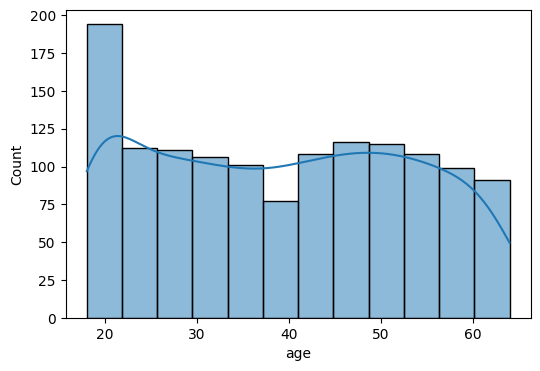

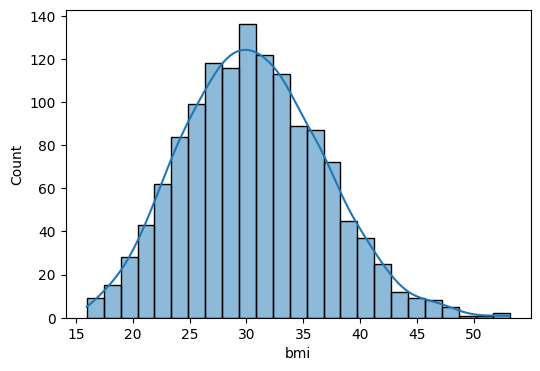

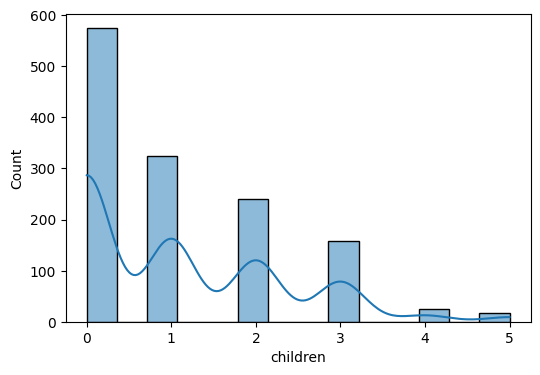

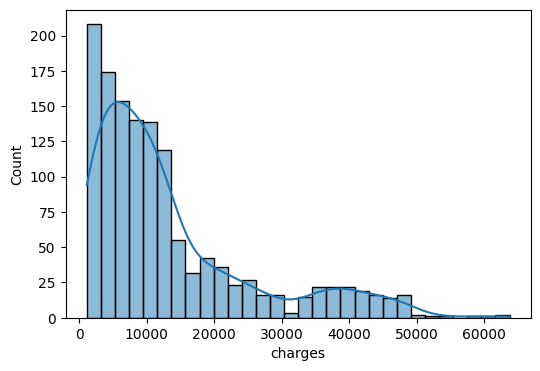

In [9]:
numeric_columns=['age','bmi','children','charges']
for i in numeric_columns:
  plt.figure(figsize=(6,4))
  sns.histplot(df[i],kde=True)

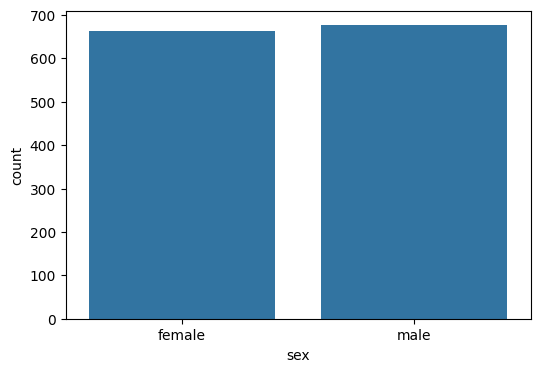

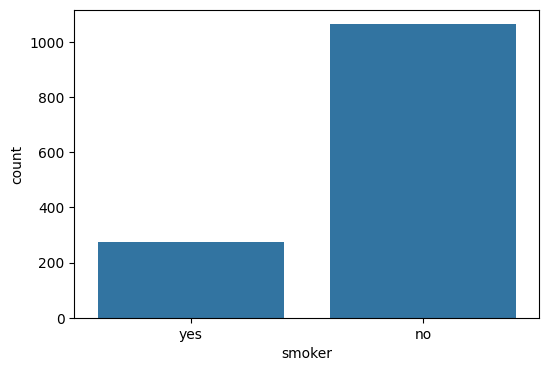

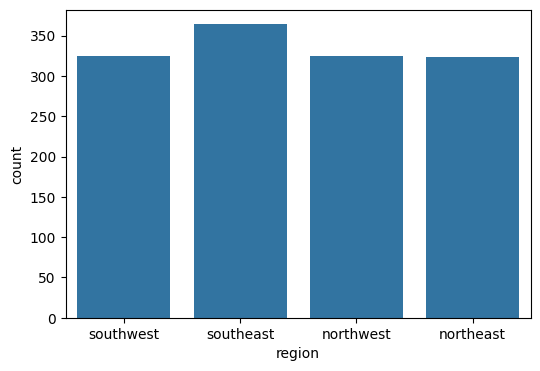

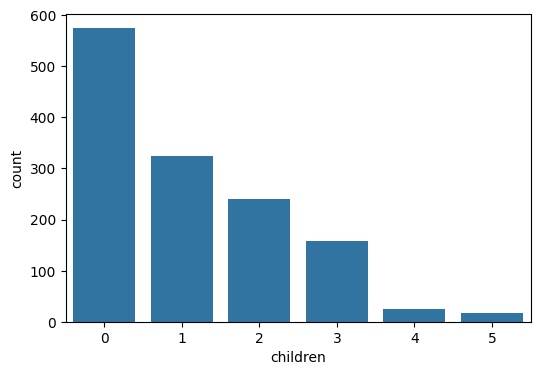

In [10]:
categorical_columns=['sex','smoker','region','children']
for i in categorical_columns:
  plt.figure(figsize=(6,4))
  sns.countplot(x=df[i])

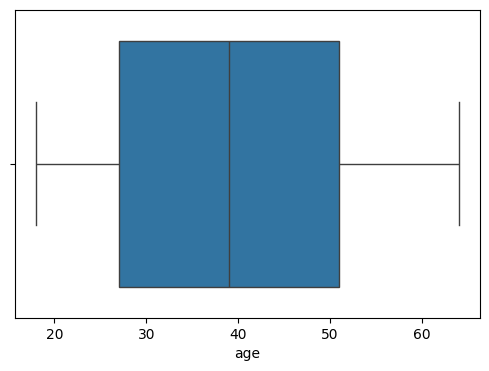

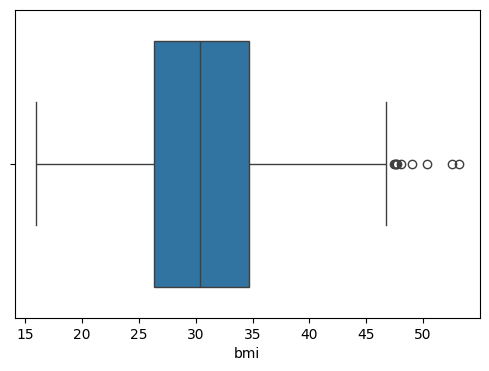

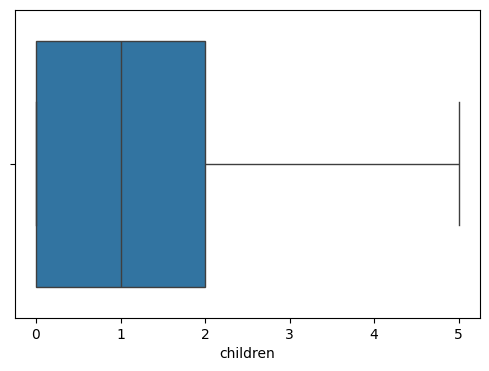

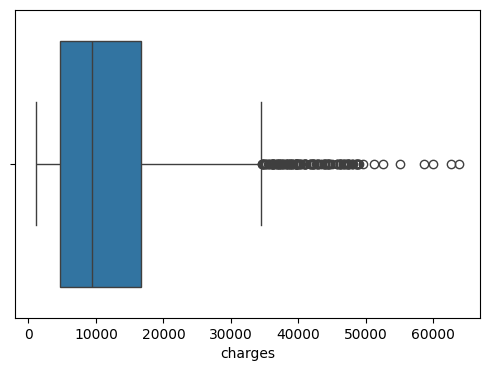

In [11]:
for i in numeric_columns:
  plt.figure(figsize=(6,4))
  sns.boxplot(x=df[i])

<Axes: >

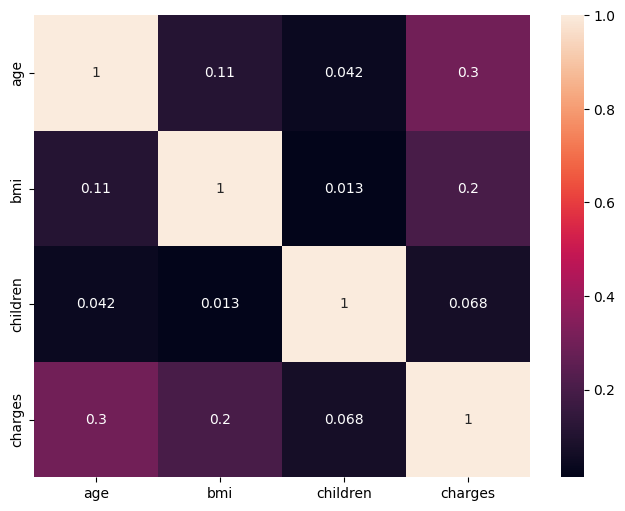

In [12]:
plt.figure(figsize=(8,6))
sns.heatmap(df.corr(numeric_only=True),annot=True)

# **Data Cleaning and Preprocessing**

In [13]:
df_cleaned=df.copy()

In [14]:
df_cleaned.head()

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


In [15]:
df_cleaned.duplicated().sum()

np.int64(1)

In [16]:
df_cleaned.drop_duplicates(inplace=True)

In [17]:
df_cleaned.shape

(1337, 7)

In [18]:
df_cleaned.isnull().sum()

,0
age,0
sex,0
bmi,0
children,0
smoker,0
region,0
charges,0


In [19]:
df_cleaned.dtypes

,0
age,int64
sex,object
bmi,float64
children,int64
smoker,object
region,object
charges,float64


In [20]:
df_cleaned['sex'].value_counts()

,count
sex,
male,675
female,662


In [21]:
df_cleaned['sex']=df_cleaned['sex'].map({'male':0,'female':1})

In [22]:
df_cleaned.head()

,age,sex,bmi,children,smoker,region,charges
0,19,1,27.900,0,yes,southwest,16884.92400
1,18,0,33.770,1,no,southeast,1725.55230
2,28,0,33.000,3,no,southeast,4449.46200
3,33,0,22.705,0,no,northwest,21984.47061
4,32,0,28.880,0,no,northwest,3866.85520


In [23]:
df_cleaned['smoker'].value_counts()

,count
smoker,
no,1063
yes,274


In [24]:
df_cleaned['smoker']=df_cleaned['smoker'].map({'no':0,'yes':1})

In [25]:
df_cleaned.head()

,age,sex,bmi,children,smoker,region,charges
0,19,1,27.900,0,1,southwest,16884.92400
1,18,0,33.770,1,0,southeast,1725.55230
2,28,0,33.000,3,0,southeast,4449.46200
3,33,0,22.705,0,0,northwest,21984.47061
4,32,0,28.880,0,0,northwest,3866.85520


In [26]:
df_cleaned.rename(columns={
    'sex':'is_female',
     'smoker':'is_smoker'},inplace=True)

In [27]:
df_cleaned.head()

,age,is_female,bmi,children,is_smoker,region,charges
0,19,1,27.900,0,1,southwest,16884.92400
1,18,0,33.770,1,0,southeast,1725.55230
2,28,0,33.000,3,0,southeast,4449.46200
3,33,0,22.705,0,0,northwest,21984.47061
4,32,0,28.880,0,0,northwest,3866.85520


In [28]:
df_cleaned['region'].value_counts()

,count
region,
southeast,364
southwest,325
northwest,324
northeast,324


In [29]:
df_cleaned = pd.get_dummies(
    df_cleaned,
    columns=['region'],
    drop_first=True
)


In [30]:
df_cleaned.head()

,age,is_female,bmi,children,is_smoker,charges,region_northwest,region_southeast,region_southwest
0,19,1,27.900,0,1,16884.92400,False,False,True
1,18,0,33.770,1,0,1725.55230,False,True,False
2,28,0,33.000,3,0,4449.46200,False,True,False
3,33,0,22.705,0,0,21984.47061,True,False,False
4,32,0,28.880,0,0,3866.85520,True,False,False


In [31]:
df_cleaned=df_cleaned.astype(int)

In [32]:
df_cleaned.head()

,age,is_female,bmi,children,is_smoker,charges,region_northwest,region_southeast,region_southwest
0,19,1,27,0,1,16884,0,0,1
1,18,0,33,1,0,1725,0,1,0
2,28,0,33,3,0,4449,0,1,0
3,33,0,22,0,0,21984,1,0,0
4,32,0,28,0,0,3866,1,0,0


# **Feature Engineering and Extraction**

In [33]:
df_cleaned['bmi_category']=pd.cut(
    df_cleaned['bmi'],
    bins=[0,18.5,24.9,29.9,np.inf],
    labels=['underweight','healthy','overweight','obese']
)

In [34]:
df_cleaned.head()

,age,is_female,bmi,children,is_smoker,charges,region_northwest,region_southeast,region_southwest,bmi_category
0,19,1,27,0,1,16884,0,0,1,overweight
1,18,0,33,1,0,1725,0,1,0,obese
2,28,0,33,3,0,4449,0,1,0,obese
3,33,0,22,0,0,21984,1,0,0,healthy
4,32,0,28,0,0,3866,1,0,0,overweight


In [35]:
print(f"maximum age {df_cleaned['age'].max()}")
print(f"Minimum age {df_cleaned['age'].min()}")

maximum age 64
Minimum age 18


In [36]:
df_cleaned['age_category']=pd.cut(
    df_cleaned['age'],
    bins=[17,29,44,59,np.inf],
    labels=['young','Adult','Middle-aged','senior']
)

In [37]:
df_cleaned

,age,is_female,bmi,children,is_smoker,charges,region_northwest,region_southeast,region_southwest,bmi_category,age_category
0,19,1,27,0,1,16884,0,0,1,overweight,young
1,18,0,33,1,0,1725,0,1,0,obese,young
2,28,0,33,3,0,4449,0,1,0,obese,young
3,33,0,22,0,0,21984,1,0,0,healthy,Adult
4,32,0,28,0,0,3866,1,0,0,overweight,Adult
...,...,...,...,...,...,...,...,...,...,...,...
1333,50,0,30,3,0,10600,1,0,0,obese,Middle-aged
1334,18,1,31,0,0,2205,0,0,0,obese,young
1335,18,1,36,0,0,1629,0,1,0,obese,young
1336,21,1,25,0,0,2007,0,0,1,overweight,young


In [38]:
df_cleaned = pd.get_dummies(
    df_cleaned,
    columns=['bmi_category', 'age_category']
)


In [39]:
df_cleaned

,age,is_female,bmi,children,is_smoker,charges,region_northwest,region_southeast,region_southwest,bmi_category_underweight,bmi_category_healthy,bmi_category_overweight,bmi_category_obese,age_category_young,age_category_Adult,age_category_Middle-aged,age_category_senior
0,19,1,27,0,1,16884,0,0,1,False,False,True,False,True,False,False,False
1,18,0,33,1,0,1725,0,1,0,False,False,False,True,True,False,False,False
2,28,0,33,3,0,4449,0,1,0,False,False,False,True,True,False,False,False
3,33,0,22,0,0,21984,1,0,0,False,True,False,False,False,True,False,False
4,32,0,28,0,0,3866,1,0,0,False,False,True,False,False,True,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1333,50,0,30,3,0,10600,1,0,0,False,False,False,True,False,False,True,False
1334,18,1,31,0,0,2205,0,0,0,False,False,False,True,True,False,False,False
1335,18,1,36,0,0,1629,0,1,0,False,False,False,True,True,False,False,False
1336,21,1,25,0,0,2007,0,0,1,False,False,True,False,True,False,False,False


In [40]:
df_cleaned=df_cleaned.astype(int)

In [41]:
df_cleaned

,age,is_female,bmi,children,is_smoker,charges,region_northwest,region_southeast,region_southwest,bmi_category_underweight,bmi_category_healthy,bmi_category_overweight,bmi_category_obese,age_category_young,age_category_Adult,age_category_Middle-aged,age_category_senior
0,19,1,27,0,1,16884,0,0,1,0,0,1,0,1,0,0,0
1,18,0,33,1,0,1725,0,1,0,0,0,0,1,1,0,0,0
2,28,0,33,3,0,4449,0,1,0,0,0,0,1,1,0,0,0
3,33,0,22,0,0,21984,1,0,0,0,1,0,0,0,1,0,0
4,32,0,28,0,0,3866,1,0,0,0,0,1,0,0,1,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1333,50,0,30,3,0,10600,1,0,0,0,0,0,1,0,0,1,0
1334,18,1,31,0,0,2205,0,0,0,0,0,0,1,1,0,0,0
1335,18,1,36,0,0,1629,0,1,0,0,0,0,1,1,0,0,0
1336,21,1,25,0,0,2007,0,0,1,0,0,1,0,1,0,0,0


In [ ]:
from sklearn.preprocessing import StandardScaler
cols=['age','bmi','children']

# NOTE: Scaling ab yahan nahi ki jayegi.
# Scaling train-test split ke BAAD hogi (sirf X_train par fit, X_test par transform)
# taake test data ki information train mein leak na ho (data leakage se bachne ke liye).

In [43]:
df_cleaned.head()

,age,is_female,bmi,children,is_smoker,charges,region_northwest,region_southeast,region_southwest,bmi_category_underweight,bmi_category_healthy,bmi_category_overweight,bmi_category_obese,age_category_young,age_category_Adult,age_category_Middle-aged,age_category_senior
0,-1.440418,1,-0.517949,-0.909234,1,16884,0,0,1,0,0,1,0,1,0,0,0
1,-1.511647,0,0.462463,-0.079442,0,1725,0,1,0,0,0,0,1,1,0,0,0
2,-0.799350,0,0.462463,1.580143,0,4449,0,1,0,0,0,0,1,1,0,0,0
3,-0.443201,0,-1.334960,-0.909234,0,21984,1,0,0,0,1,0,0,0,1,0,0
4,-0.514431,0,-0.354547,-0.909234,0,3866,1,0,0,0,0,1,0,0,1,0,0


In [44]:
df_cleaned.shape

(1337, 17)

In [45]:
df_cleaned.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1337 entries, 0 to 1337
Data columns (total 17 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   age                       1337 non-null   float64
 1   is_female                 1337 non-null   int64  
 2   bmi                       1337 non-null   float64
 3   children                  1337 non-null   float64
 4   is_smoker                 1337 non-null   int64  
 5   charges                   1337 non-null   int64  
 6   region_northwest          1337 non-null   int64  
 7   region_southeast          1337 non-null   int64  
 8   region_southwest          1337 non-null   int64  
 9   bmi_category_underweight  1337 non-null   int64  
 10  bmi_category_healthy      1337 non-null   int64  
 11  bmi_category_overweight   1337 non-null   int64  
 12  bmi_category_obese        1337 non-null   int64  
 13  age_category_young        1337 non-null   int64  
 14  age_category_

In [46]:
from scipy.stats import pearsonr   # Pearson correlation function import

# List of features to check against target
selected_features = [
    'age', 'bmi', 'children', 'is_female', 'is_smoker',
    'region_northwest', 'region_southeast', 'region_southwest',
    'bmi_category_underweight', 'bmi_category_healthy', 'bmi_category_overweight','bmi_category_obese',
    'age_category_young', 'age_category_Adult', 'age_category_Middle-aged', 'age_category_senior'
]
corelation={
    feature: pearsonr(df_cleaned[feature], df_cleaned['charges'])[0]
    for feature in selected_features
}
corelation_df=pd.DataFrame(list(corelation.items()),columns=['feature','Pearson correlation'])
corelation_df.sort_values(by='Pearson correlation',ascending=False)


,feature,Pearson correlation
4,is_smoker,0.787234
0,age,0.298309
15,age_category_senior,0.200975
11,bmi_category_obese,0.200348
1,bmi,0.196236
14,age_category_Middle-aged,0.146519
6,region_southeast,0.073577
2,children,0.067390
5,region_northwest,-0.038695
13,age_category_Adult,-0.041934


In [47]:
df_cleaned.head(1)

,age,is_female,bmi,children,is_smoker,charges,region_northwest,region_southeast,region_southwest,bmi_category_underweight,bmi_category_healthy,bmi_category_overweight,bmi_category_obese,age_category_young,age_category_Adult,age_category_Middle-aged,age_category_senior
0,-1.440418,1,-0.517949,-0.909234,1,16884,0,0,1,0,0,1,0,1,0,0,0


In [48]:
cat_features = [
    'is_female',
    'is_smoker',
    'region_northwest',
    'region_southeast',
    'region_southwest',
    'bmi_category_underweight',
    'bmi_category_healthy',
    'bmi_category_overweight',
    'bmi_category_obese',
    'age_category_young',
    'age_category_Adult',
    'age_category_Middle-aged',
    'age_category_senior'
]


In [49]:
from scipy.stats import chi2_contingency
import pandas as pd

# Significance level
alpha = 0.05

# Target ko 4 quantile bins me todna
df_cleaned['charges_bin'] = pd.qcut(df_cleaned['charges'], q=4, labels=False)

chi2_results = {}

# cat_features list me categorical columns honi chahiye
for col in cat_features:
    contingency = pd.crosstab(df_cleaned[col], df_cleaned['charges_bin'])
    chi2_stat, p_val, _, _ = chi2_contingency(contingency)
    decision = 'Reject Null (Keep Feature)' if p_val < alpha else 'Accept Null (Drop Feature)'
    chi2_results[col] = {
        'chi2_statistic': chi2_stat,
        'p_value': p_val,
        'Decision': decision
    }

# Results ko DataFrame me convert karna aur sort karna
chi2_df = pd.DataFrame(chi2_results).T
chi2_df = chi2_df.sort_values(by='p_value')
chi2_df


,chi2_statistic,p_value,Decision
is_smoker,848.219178,0.0,Reject Null (Keep Feature)
age_category_young,628.527535,0.0,Reject Null (Keep Feature)
age_category_Adult,379.772442,0.0,Reject Null (Keep Feature)
age_category_Middle-aged,331.738773,0.0,Reject Null (Keep Feature)
age_category_senior,161.971585,0.0,Reject Null (Keep Feature)
region_southeast,15.998167,0.001135,Reject Null (Keep Feature)
is_female,10.258784,0.01649,Reject Null (Keep Feature)
bmi_category_obese,8.515711,0.036473,Reject Null (Keep Feature)
region_southwest,5.091893,0.165191,Accept Null (Drop Feature)
bmi_category_overweight,4.25149,0.235557,Accept Null (Drop Feature)


In [50]:
df_cleaned.head(1)

,age,is_female,bmi,children,is_smoker,charges,region_northwest,region_southeast,region_southwest,bmi_category_underweight,bmi_category_healthy,bmi_category_overweight,bmi_category_obese,age_category_young,age_category_Adult,age_category_Middle-aged,age_category_senior,charges_bin
0,-1.440418,1,-0.517949,-0.909234,1,16884,0,0,1,0,0,1,0,1,0,0,0,3


In [51]:
final_df=df_cleaned[['age','is_female','bmi','children','is_smoker',
                     'charges','region_southeast','bmi_category_obese',
                     'age_category_young','age_category_Adult',
                     'age_category_Middle-aged','age_category_senior'

]]

In [52]:
final_df.head()

,age,is_female,bmi,children,is_smoker,charges,region_southeast,bmi_category_obese,age_category_young,age_category_Adult,age_category_Middle-aged,age_category_senior
0,-1.440418,1,-0.517949,-0.909234,1,16884,0,0,1,0,0,0
1,-1.511647,0,0.462463,-0.079442,0,1725,1,1,1,0,0,0
2,-0.799350,0,0.462463,1.580143,0,4449,1,1,1,0,0,0
3,-0.443201,0,-1.334960,-0.909234,0,21984,0,0,0,1,0,0
4,-0.514431,0,-0.354547,-0.909234,0,3866,0,0,0,1,0,0


In [53]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression

In [54]:
X=final_df.drop('charges',axis=1)
y=final_df['charges']

In [55]:
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.20,random_state=42)

### Feature Scaling (after train-test split, to avoid data leakage)

In [ ]:
# Data leakage se bachne ke liye: scaler ko sirf X_train par fit karein,
# X_test par sirf transform (koi fit nahi) - taake test set 'unseen' hi rahe.
X_train = X_train.copy()
X_test = X_test.copy()

scaler = StandardScaler()
X_train[cols] = scaler.fit_transform(X_train[cols])
X_test[cols] = scaler.transform(X_test[cols])

In [56]:
model=LinearRegression()
model.fit(X_train,y_train)

LinearRegression()

In [57]:
y_predict=model.predict(X_test)

In [58]:
from sklearn.metrics import r2_score,mean_absolute_error,mean_squared_error

In [59]:
r2=r2_score(y_test,y_predict)
r2
n=X_test.shape[0]
p=X_test.shape[1]
adjusted_r2=1-((1-r2)*(n-1)/(n-p-1))
adjusted_r2

0.7926954805865061

In [60]:
coef_df = pd.DataFrame({
    'Feature': X.columns,
    'Coefficient': model.coef_
}).sort_values(by='Coefficient', ascending=False)
print(coef_df)

                     Feature   Coefficient
4                  is_smoker  23037.850251
0                        age   3685.027687
6         bmi_category_obese   3016.048736
3                   children    853.091702
7         age_category_young    795.949295
10       age_category_senior    790.781806
2                        bmi    655.477854
1                  is_female     85.193382
5           region_southeast   -245.052024
9   age_category_Middle-aged   -275.059439
8         age_category_Adult  -1311.671662


In [61]:
print(f"Mean Absolute Error (MAE): {mean_absolute_error(y_test, y_predict):.2f}")
print(f"Root Mean Squared Error (RMSE): {np.sqrt(mean_squared_error(y_test, y_predict)):.2f}")

Mean Absolute Error (MAE): 4358.73
Root Mean Squared Error (RMSE): 6043.51


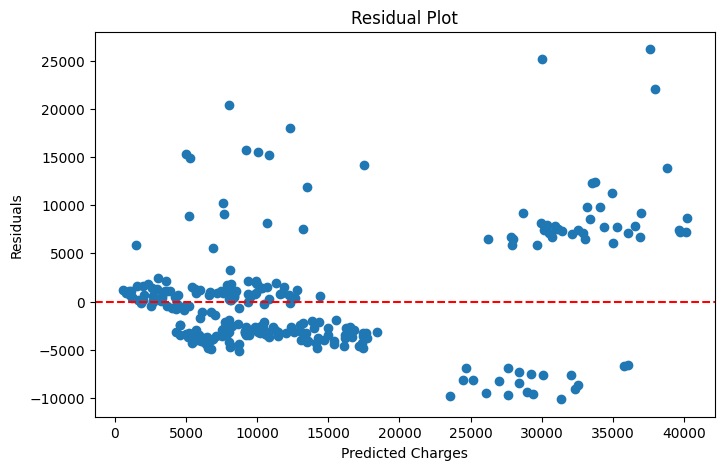

In [62]:
plt.figure(figsize=(8,5))
residuals = y_test - y_predict
plt.scatter(y_predict, residuals)
plt.axhline(y=0, color='r', linestyle='--')
plt.xlabel('Predicted Charges')
plt.ylabel('Residuals')
plt.title('Residual Plot')
plt.show()

In [64]:
print("Please enter customer details:")

age = float(input("Enter Age: "))
gender = input("Enter Gender (male/female): ").strip().lower()
bmi = float(input("Enter BMI: "))
children = int(input("Enter Number of Children: "))
smoker = input("Is the person a smoker? (yes/no): ").strip().lower()
region = input("Enter Region (southeast/southwest/northwest/northeast): ").strip().lower()

# Encoding (jaise aapne pehle kiya tha)
is_female = 1 if gender == "female" else 0
is_smoker = 1 if smoker == "yes" else 0
region_southeast = 1 if region == "southeast" else 0

# 1. DataFrame Banana
new_customer = pd.DataFrame([{
    'age': age,
    'is_female': is_female,
    'bmi': bmi,
    'children': children,
    'is_smoker': is_smoker,
    'region_southeast': region_southeast,
    'bmi_category_obese': 1 if bmi >= 30 else 0,  # Simple condition
    'age_category_young': 1 if age < 30 else 0,
    'age_category_Adult': 1 if 30 <= age < 45 else 0,
    'age_category_Middle-aged': 1 if 45 <= age < 60 else 0,
    'age_category_senior': 1 if age >= 60 else 0
}])

# 2. Scaling
cols_to_scale = ['age', 'bmi', 'children']
new_customer[cols_to_scale] = scaler.transform(new_customer[cols_to_scale])

# 3. Prediction
predicted_charge = model.predict(new_customer)
print(f"\n💰 Predicted Insurance Charge: ${predicted_charge[0]:,.2f}")

Please enter customer details:
Enter Age: 45
Enter Gender (male/female): male
Enter BMI: 28.6
Enter Number of Children: 5
Is the person a smoker? (yes/no): no
Enter Region (southeast/southwest/northwest/northeast): southeast

💰 Predicted Insurance Charge: $10,657.91
